In [1]:
import torch
import torchvision.models as models
import torch.nn as nn
from utils import get_loaders, train, plot_training_history, plot_sample_predictions, set_seed, plot_confusion_matrix, plot_cumulative_training_history, evaluate_model
from pathlib import Path
import os

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: cuda


In [ ]:
DATA_DIR = Path("../data")

TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

BATCH_SIZE = 256

In [ ]:
train_loader, valid_loader, test_loader = get_loaders(
    train_dir=TRAIN_DIR, 
    valid_dir=VALID_DIR,
    test_dir=TEST_DIR, 
    image_size=224, 
    batch_size=BATCH_SIZE
)

In [4]:
set_seed(42)

#### Training AlexNet model from scratch

In [ ]:
set_seed(42)

alexnet_model = models.alexnet(weights=None).to(device)
alexnet_model.classifier[-1] = nn.Linear(alexnet_model.classifier[-1].in_features, 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(alexnet_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.3)

In [ ]:
alexnet_training_history = train(alexnet_model, train_loader, valid_loader, criterion, optimizer, scheduler, 
                        device=device, num_epochs=15, checkpoint_name='alexnet')

Epoch 1/15 | Train Loss: 1.7835 | Valid Loss: 1.5374 | Valid Acc: 0.4203
Epoch 2/15 | Train Loss: 1.4966 | Valid Loss: 1.4372 | Valid Acc: 0.4724
Epoch 3/15 | Train Loss: 1.3889 | Valid Loss: 1.3697 | Valid Acc: 0.5021
Epoch 4/15 | Train Loss: 1.3193 | Valid Loss: 1.2746 | Valid Acc: 0.5355
Epoch 5/15 | Train Loss: 1.2714 | Valid Loss: 1.2629 | Valid Acc: 0.5453
Epoch 6/15 | Train Loss: 1.2331 | Valid Loss: 1.2123 | Valid Acc: 0.5640
Epoch 7/15 | Train Loss: 1.1962 | Valid Loss: 1.2105 | Valid Acc: 0.5625
Epoch 8/15 | Train Loss: 1.1674 | Valid Loss: 1.1762 | Valid Acc: 0.5780
Epoch 9/15 | Train Loss: 1.1462 | Valid Loss: 1.1780 | Valid Acc: 0.5780
Epoch 10/15 | Train Loss: 1.1233 | Valid Loss: 1.1939 | Valid Acc: 0.5719
Epoch 11/15 | Train Loss: 1.1016 | Valid Loss: 1.1546 | Valid Acc: 0.5842
Epoch 12/15 | Train Loss: 1.0891 | Valid Loss: 1.1294 | Valid Acc: 0.5966
Epoch 13/15 | Train Loss: 1.0648 | Valid Loss: 1.2032 | Valid Acc: 0.5717
Epoch 14/15 | Train Loss: 1.0461 | Valid Loss: 

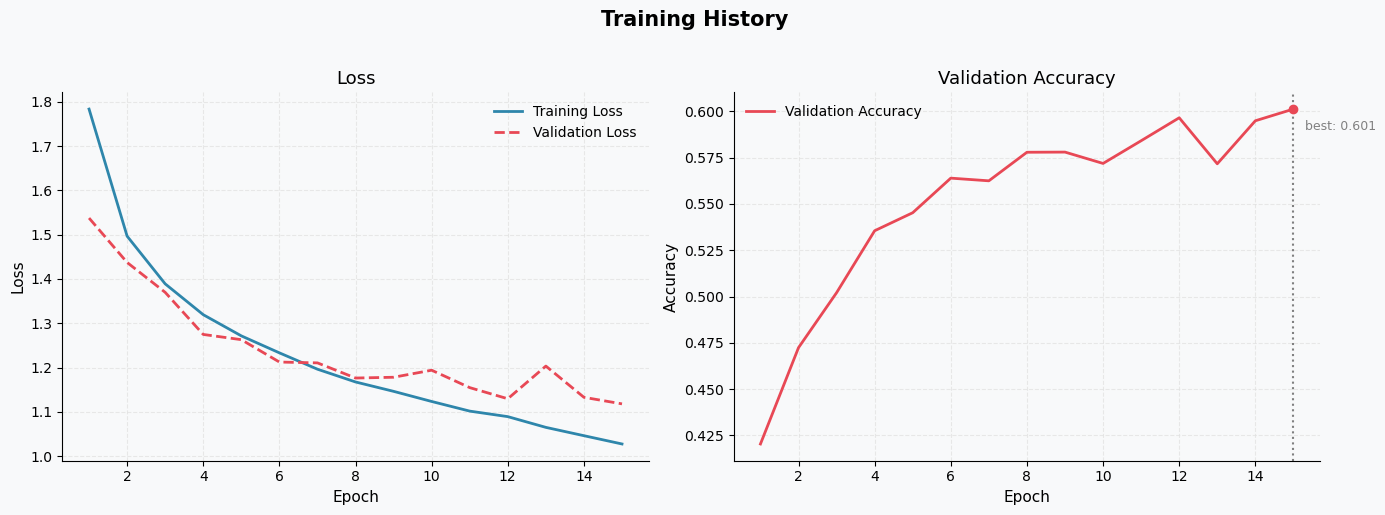

In [ ]:
plot_training_history(alexnet_training_history)

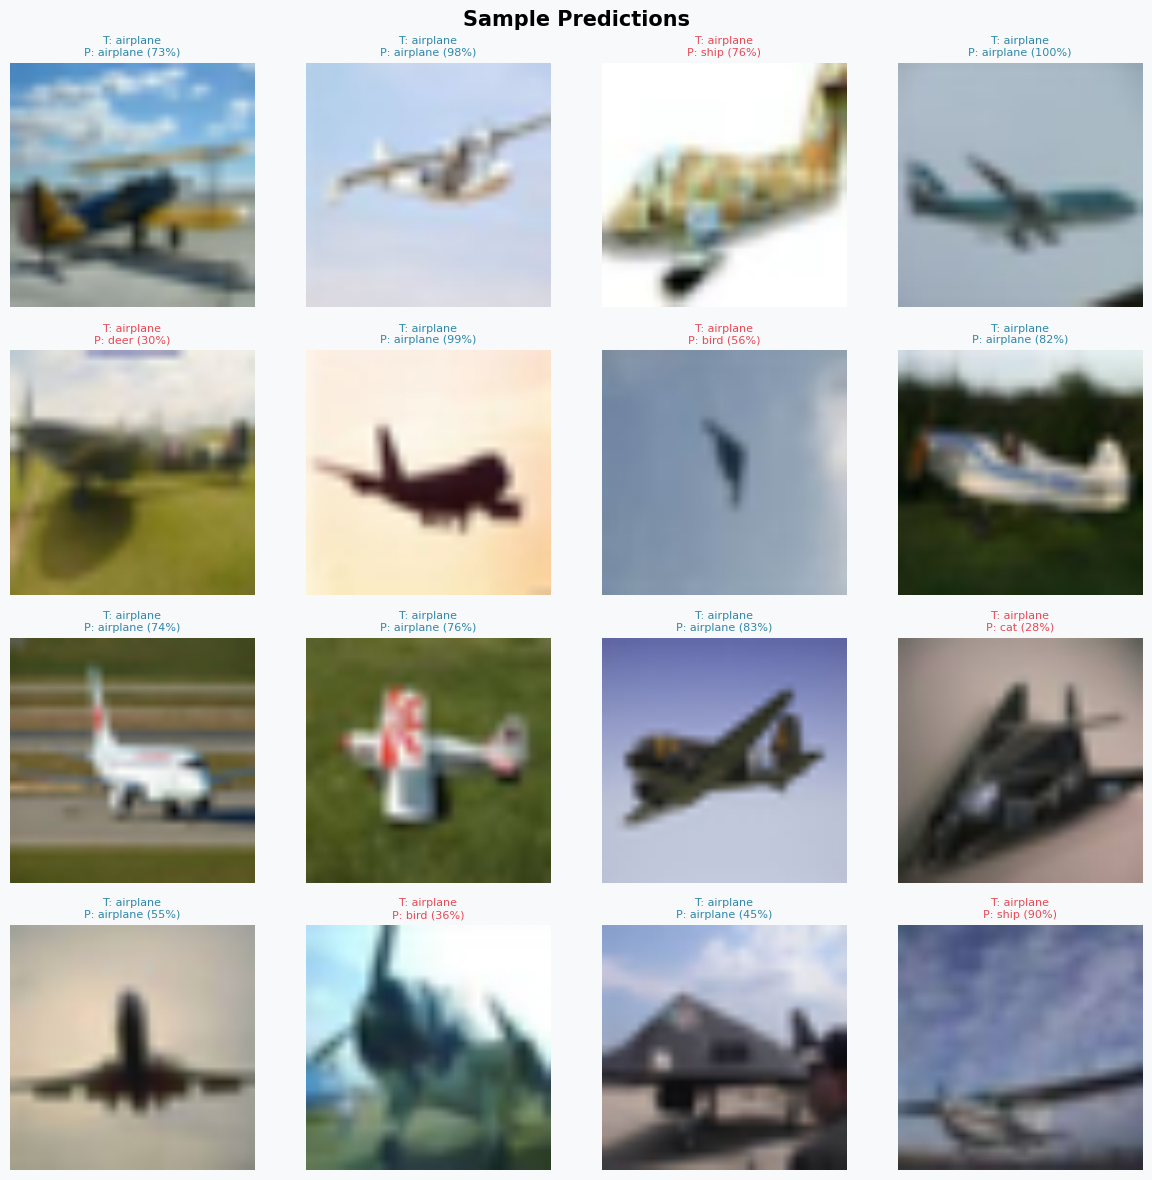

In [ ]:
plot_sample_predictions(alexnet_model, valid_loader, device)

In [ ]:
evaluate_model(alexnet_model, test_loader, criterion, device)

(0.5986111164093018, 1.1240658413992988)

### **Modified AlexNet**

In [ ]:
set_seed(42)

In [ ]:
from alexnet import ModifiedAlexNet

In [6]:
BATCH_SIZE = 256
IMAGE_SIZE = 32

In [ ]:
train_loader, valid_loader, test_loader = get_loaders(
    train_dir=TRAIN_DIR, 
    valid_dir=VALID_DIR,
    test_dir=TEST_DIR, 
    image_size=IMAGE_SIZE, 
    batch_size=BATCH_SIZE,
)

In [ ]:
model_mod2_alex_scheduler = ModifiedAlexNet(num_classes=10).to(device)

In [9]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mod2_alex_scheduler.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.3)

In [10]:
mod_2_alexnet_sched_training_history = train(
    model_mod2_alex_scheduler,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    scheduler,
    device=device,
    num_epochs=20,
    checkpoint_name='modified_2_alexnet_sched_32_seed42')

Epoch 1/20 | Train Loss: 1.5500 | Valid Loss: 1.4604 | Valid Acc: 0.4716
Epoch 2/20 | Train Loss: 1.2237 | Valid Loss: 1.1514 | Valid Acc: 0.5841
Epoch 3/20 | Train Loss: 1.0837 | Valid Loss: 1.0343 | Valid Acc: 0.6290
Epoch 4/20 | Train Loss: 0.9882 | Valid Loss: 1.0779 | Valid Acc: 0.6128
Epoch 5/20 | Train Loss: 0.9097 | Valid Loss: 1.0226 | Valid Acc: 0.6350
Epoch 6/20 | Train Loss: 0.8403 | Valid Loss: 1.0083 | Valid Acc: 0.6588
Epoch 7/20 | Train Loss: 0.7852 | Valid Loss: 0.8438 | Valid Acc: 0.7029
Epoch 8/20 | Train Loss: 0.7199 | Valid Loss: 0.8831 | Valid Acc: 0.6926
Epoch 9/20 | Train Loss: 0.6590 | Valid Loss: 0.9295 | Valid Acc: 0.6870
Epoch 10/20 | Train Loss: 0.6041 | Valid Loss: 0.8858 | Valid Acc: 0.7004
Epoch 11/20 | Train Loss: 0.5518 | Valid Loss: 0.9828 | Valid Acc: 0.6905
Epoch 12/20 | Train Loss: 0.3744 | Valid Loss: 0.8134 | Valid Acc: 0.7418
Epoch 13/20 | Train Loss: 0.3123 | Valid Loss: 0.8563 | Valid Acc: 0.7443
Epoch 14/20 | Train Loss: 0.2713 | Valid Loss: 

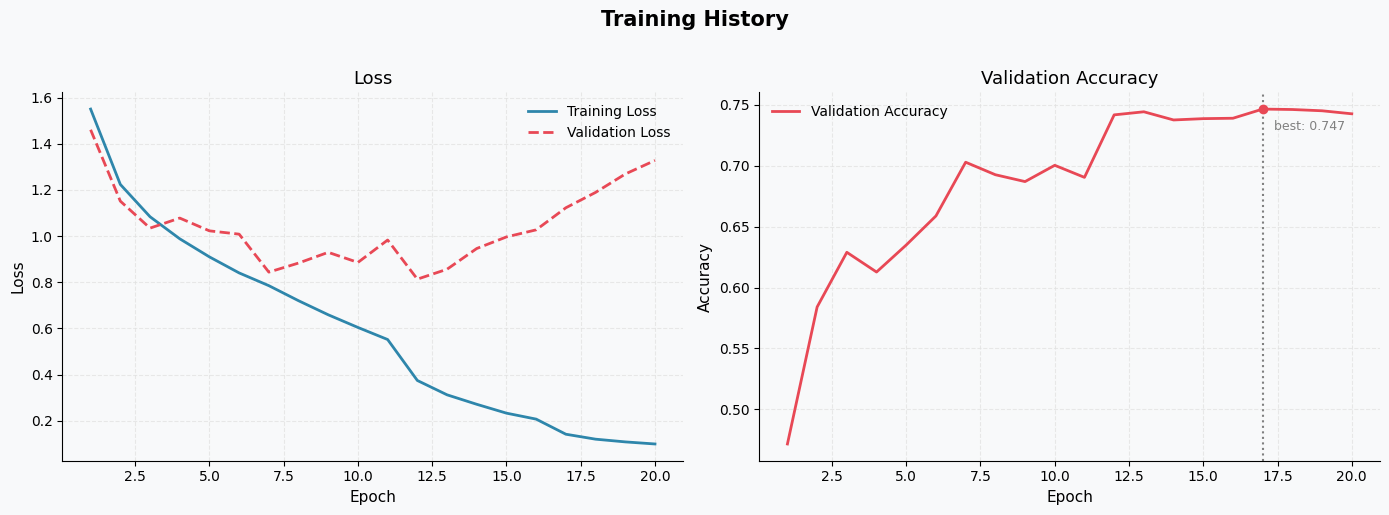

In [11]:
plot_training_history(mod_2_alexnet_sched_training_history)

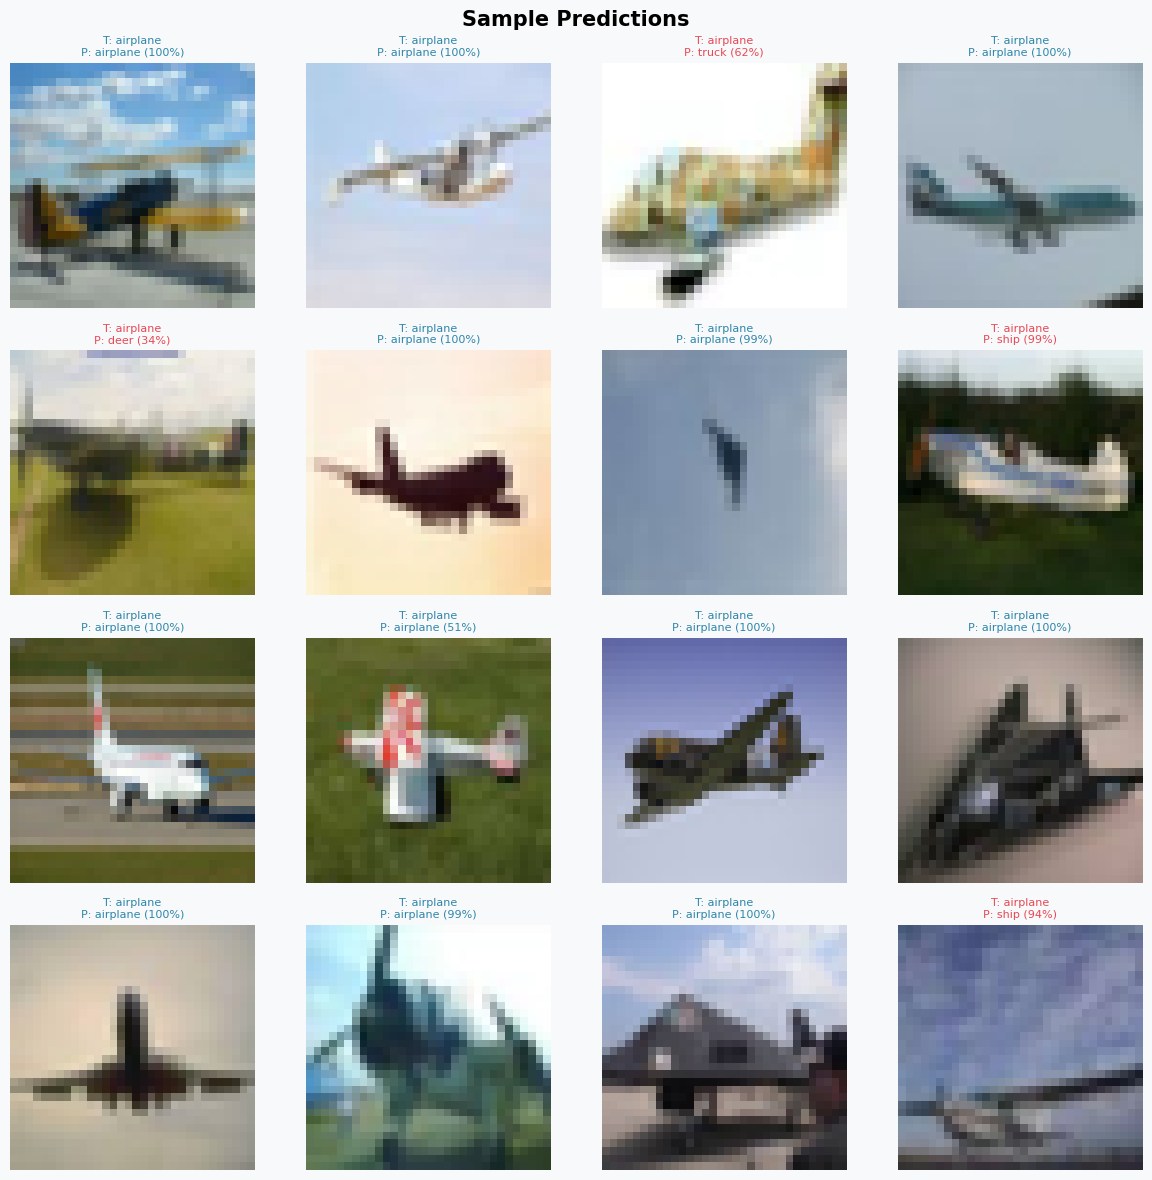

In [12]:
plot_sample_predictions(model_mod2_alex_scheduler, valid_loader, device)

In [13]:
evaluate_model(model_mod2_alex_scheduler, test_loader, criterion, device)

(0.7398777604103088, 1.3528760971281264)